# M4 Triplet: R(s) vs R_final — MISTRAL Detector
Score Human + Original AI + LIT3-Humanized (Kimi) on unseen M4 benchmark.
Compare R(s) (original DNA-DetectLLM) vs R_final (our proposed robust score).

In [1]:
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'torch==2.5.1+cu121', 'torchvision==0.20.1+cu121', '--index-url', 'https://download.pytorch.org/whl/cu121', '-q'])
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'transformers==4.46.3', 'accelerate==1.1.1', 'bitsandbytes', 'scipy', 'scikit-learn', '-q'])
import torch; print(f'PyTorch {torch.__version__}, CUDA: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    p = torch.cuda.get_device_properties(0); print(f'GPU: {p.name}, compute {p.major}.{p.minor}')
    x = torch.randn(2,2).cuda(); print(f'OK: {(x@x).sum().item():.2f}'); del x

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.4/780.4 MB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 75.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 43.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 93.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 6.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 14.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.0 MB 9.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 MB 9.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torchaudio 2.10.0+cu128 requires torch==2.10.0, but you have torch 2.5.1+cu121 which is incompatible.


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 65.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 333.2/333.2 kB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 29.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 30.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 80.3 MB/s eta 0:00:00
PyTorch 2.5.1+cu121, CUDA: True
GPU: Tesla P100-PCIE-16GB, compute 6.0
OK: 2.97


In [2]:
import gc, os, sys, json, shutil, warnings
import numpy as np
import torch, torch.nn.functional as F
from tqdm import tqdm
from scipy import stats
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')
BASE = '/kaggle/input'
df = ds = None
for r, dirs, files in os.walk(BASE):
    for f in files:
        if f == 'm4_literature_dataset.json': df = os.path.join(r, f)
        if f == 'metrics.py' and 'dna' not in os.path.basename(r): ds = r
    for d in dirs:
        if d == 'dna_detectllm':
            c = os.path.join(r, d)
            if os.path.isfile(os.path.join(c, '__init__.py')): ds = c
# Try to find dna module in various locations
if not ds:
    for r, dirs, files in os.walk(BASE):
        if 'metrics.py' in files:
            ds = r; break
if ds and not os.path.exists('dna_detectllm'):
    os.makedirs('dna_detectllm', exist_ok=True)
    for f in os.listdir(ds):
        if f.endswith('.py'): shutil.copy(os.path.join(ds, f), 'dna_detectllm/')
    if not os.path.exists('dna_detectllm/__init__.py'):
        open('dna_detectllm/__init__.py', 'w').close()
    print(f'Copied dna module from {ds}')
sys.path.insert(0, os.getcwd())
from dna_detectllm.metrics import sum_perplexity, entropy
os.environ['HF_TOKEN'] = 'YOUR_HF_TOKEN'
with open(df) as f: dataset = json.load(f)
print(f'Human: {len(dataset["human_texts"])}, AI: {len(dataset["original_ai_texts"])}, Humanized: {sum(1 for x in dataset["humanized"]["kimi_lit3"] if x)}')

Copied dna module from /kaggle/input/datasets/pramukhswami/dna-module/dna_detectllm/dna_detectllm
Human: 100, AI: 100, Humanized: 100


In [3]:
from transformers import AutoModelForCausalLM, AutoTokenizer
import ctypes
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'
gc.collect(); torch.cuda.empty_cache()
OBS_MODEL = 'mistralai/Mistral-7B-v0.1'
PERF_MODEL = 'mistralai/Mistral-7B-Instruct-v0.1'
tokenizer = AutoTokenizer.from_pretrained(OBS_MODEL)
if tokenizer.pad_token is None: tokenizer.pad_token = tokenizer.eos_token
MAX_LEN = 256; DEVICE = 'cuda:0'
cc = torch.cuda.get_device_properties(0)
if (cc.major, cc.minor) >= (7,0):
    from transformers import BitsAndBytesConfig
    qc = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_compute_dtype=torch.float16, bnb_4bit_quant_type='nf4')
    lk = dict(quantization_config=qc, device_map='auto', low_cpu_mem_usage=True); MAX_LEN = 512
else:
    lk = dict(torch_dtype=torch.float16, device_map='auto', low_cpu_mem_usage=True)
print(f'Loading {OBS_MODEL}...')
observer = AutoModelForCausalLM.from_pretrained(OBS_MODEL, **lk); observer.eval()
gc.collect(); torch.cuda.empty_cache()
try: ctypes.CDLL('libc.so.6').malloc_trim(0)
except: pass
print(f'Loading {PERF_MODEL}...')
performer = AutoModelForCausalLM.from_pretrained(PERF_MODEL, **lk); performer.eval()
print(f'Models loaded. MAX_LEN={MAX_LEN}')

tokenizer_config.json:   0%|          | 0.00/996 [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

Loading mistralai/Mistral-7B-v0.1...


...

model-00001-of-00002.safetensors:   0%|          | 0.00/9.94G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/4.54G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

Models loaded. MAX_LEN=256


In [4]:
@torch.inference_mode()
def compute_all(text):
    torch.cuda.empty_cache()
    enc = tokenizer(text, return_tensors='pt', truncation=True, max_length=MAX_LEN, return_token_type_ids=False)
    eg = {k: v.to(DEVICE) for k, v in enc.items()}
    ol = observer(**eg).logits.float()
    pl = performer(**eg).logits.float()
    class E:
        def __init__(s, d): s.input_ids = d['input_ids']; s.attention_mask = d['attention_mask']
        def to(s, dev): s.input_ids = s.input_ids.to(dev); s.attention_mask = s.attention_mask.to(dev); return s
    eo = E(eg)
    ppl = sum_perplexity(eo, pl); xppl = entropy(ol, pl, eo, tokenizer.pad_token_id)
    rs = float(ppl[0] / (2 * xppl[0]))
    shifted = pl[..., :-1, :]; labels = eg['input_ids'][..., 1:]; attn = eg['attention_mask'][..., 1:]
    ce = F.cross_entropy(shifted.transpose(1,2), labels, reduction='none')
    S = ce[attn.bool()].cpu().numpy()
    if len(S) < 5: del ol, pl, eg; return None
    ce_var = float(np.var(S))
    obs_top = ol[..., :-1, :].argmax(dim=-1); perf_top = shifted.argmax(dim=-1)
    agree = (obs_top == perf_top).float()[attn.bool()].cpu().numpy()
    agree_rate = float(np.mean(agree))
    pe = -(F.softmax(pl[..., :-1, :], dim=-1) * F.log_softmax(pl[..., :-1, :], dim=-1)).sum(-1)
    H = pe[attn.bool()].cpu().numpy(); H_med = np.median(H); conf = H < H_med
    coherence = float(np.mean(S[conf]) - np.mean(S[~conf])) if conf.sum() > 0 and (~conf).sum() > 0 else 0.0
    del ol, pl, eg
    return {'rs': rs, 'ce_var': ce_var, 'agree_rate': agree_rate, 'coherence': coherence}
print(f'Test: {compute_all("Hello world test.")}')

Test: None


In [5]:
# Score all 3 groups
CKPT = 'triplet_ckpt.json'
if os.path.exists(CKPT):
    scores = json.load(open(CKPT)); print(f'Checkpoint: {list(scores.keys())}')
else:
    scores = {}
for gname, texts in [('human', dataset['human_texts']), ('original_ai', dataset['original_ai_texts']), ('humanized_lit3', dataset['humanized']['kimi_lit3'])]:
    if gname in scores: print(f'{gname}: done'); continue
    print(f'Scoring {gname}...')
    sc = []
    for t in tqdm(texts, desc=gname):
        if t is None: sc.append(None)
        else:
            try: sc.append(compute_all(t))
            except Exception as e: print(f'Err: {e}'); sc.append(None)
    scores[gname] = sc
    with open(CKPT, 'w') as f: json.dump(scores, f)
print('All scored!')

Scoring human...


human: 100%|██████████| 100/100 [07:32<00:00,  4.52s/it]


Scoring original_ai...


original_ai: 100%|██████████| 100/100 [07:24<00:00,  4.44s/it]


Scoring humanized_lit3...


humanized_lit3: 100%|██████████| 100/100 [07:29<00:00,  4.50s/it]

All scored!


In [6]:
# === ANALYSIS: R(s) vs R_final ===
hv = [s for s in scores['human'] if s]
av = [s for s in scores['original_ai'] if s]
lv = [s for s in scores['humanized_lit3'] if s]

# Human baselines for R_final
h_cev = [s['ce_var'] for s in hv]; h_agr = [s['agree_rate'] for s in hv]; h_coh = [s['coherence'] for s in hv]
CM, CS = np.mean(h_cev), np.std(h_cev)
AM, AS = np.mean(h_agr), np.std(h_agr)
OM, OS = np.mean(h_coh), np.std(h_coh)

def R_final(s, k=1.0):
    rs = s['rs']
    p1 = max(0.1, 1 - 0.1 * max(0, s['ce_var'] - (CM + k * CS)))
    p2 = max(0.1, 1 - 3.0 * max(0, (AM - k * AS) - s['agree_rate']))
    p3 = max(0.1, 1 - 0.5 * max(0, (OM - k * OS) - s['coherence']))
    return rs * p1 * p2 * p3

print(f'MISTRAL DETECTOR — M4 TRIPLET RESULTS')
print('='*60)
print(f'Human baseline: ce_var={CM:.2f}, agree={AM:.4f}, coherence={OM:.2f}')
print()
print(f'{"Score":<20} {"H vs AI":>10} {"H vs Humanized":>15}')
print('-'*48)

for name, fn in [('R(s) original', lambda s: s['rs']), ('R_final (k=0.5)', lambda s: R_final(s, 0.5)), ('R_final (k=1.0)', lambda s: R_final(s, 1.0)), ('R_final (k=1.5)', lambda s: R_final(s, 1.5))]:
    hs = [fn(s) for s in hv]
    ais = [fn(s) for s in av]
    ls = [fn(s) for s in lv]
    a1 = roc_auc_score([1]*len(hs)+[0]*len(ais), hs+ais)
    a2 = roc_auc_score([1]*len(hs)+[0]*len(ls), hs+ls)
    print(f'{name:<20} {a1:>10.4f} {a2:>15.4f}')

print()
print('If R_final keeps H vs AI high AND improves H vs Humanized:')
print('  → R_final is strictly better than R(s) for robust detection.')

MISTRAL DETECTOR — M4 TRIPLET RESULTS
Human baseline: ce_var=7.89, agree=0.7671, coherence=-2.27

Score                   H vs AI  H vs Humanized
------------------------------------------------
R(s) original            0.8623          0.4752
R_final (k=0.5)          0.7949          0.9671
R_final (k=1.0)          0.8229          0.9450
R_final (k=1.5)          0.8414          0.8979

If R_final keeps H vs AI high AND improves H vs Humanized:
  → R_final is strictly better than R(s) for robust detection.


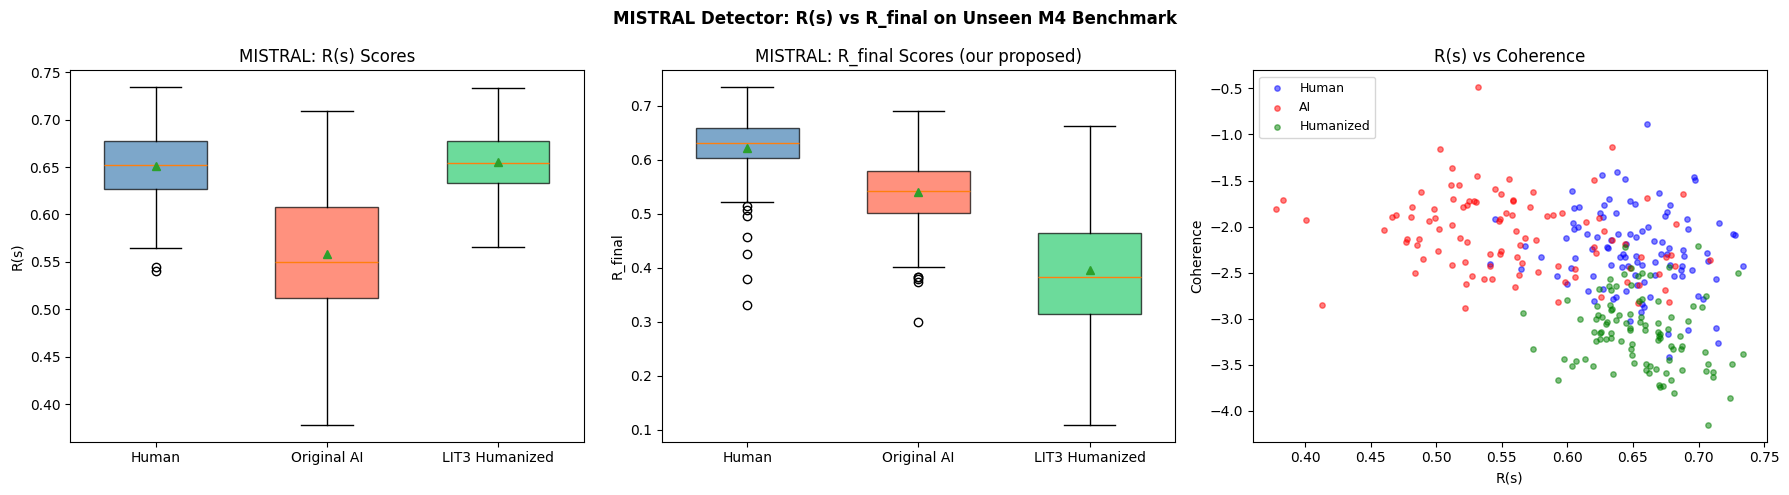

In [7]:
# === PLOTS ===
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Boxplot of R(s)
rs_h = [s['rs'] for s in hv]; rs_a = [s['rs'] for s in av]; rs_l = [s['rs'] for s in lv]
bp = axes[0].boxplot([rs_h, rs_a, rs_l], patch_artist=True, widths=0.6, showmeans=True)
for p, c in zip(bp['boxes'], ['steelblue','tomato','#2ecc71']): p.set_facecolor(c); p.set_alpha(0.7)
axes[0].set_xticklabels(['Human','Original AI','LIT3 Humanized'])
axes[0].set_ylabel('R(s)'); axes[0].set_title('MISTRAL: R(s) Scores')

# 2. Boxplot of R_final
rf_h = [R_final(s) for s in hv]; rf_a = [R_final(s) for s in av]; rf_l = [R_final(s) for s in lv]
bp2 = axes[1].boxplot([rf_h, rf_a, rf_l], patch_artist=True, widths=0.6, showmeans=True)
for p, c in zip(bp2['boxes'], ['steelblue','tomato','#2ecc71']): p.set_facecolor(c); p.set_alpha(0.7)
axes[1].set_xticklabels(['Human','Original AI','LIT3 Humanized'])
axes[1].set_ylabel('R_final'); axes[1].set_title('MISTRAL: R_final Scores (our proposed)')

# 3. Scatter R(s) vs coherence
axes[2].scatter([s['rs'] for s in hv], [s['coherence'] for s in hv], c='blue', alpha=0.5, s=15, label='Human')
axes[2].scatter([s['rs'] for s in av], [s['coherence'] for s in av], c='red', alpha=0.5, s=15, label='AI')
axes[2].scatter([s['rs'] for s in lv], [s['coherence'] for s in lv], c='green', alpha=0.5, s=15, label='Humanized')
axes[2].set_xlabel('R(s)'); axes[2].set_ylabel('Coherence'); axes[2].set_title('R(s) vs Coherence')
axes[2].legend(fontsize=9)

plt.suptitle('MISTRAL Detector: R(s) vs R_final on Unseen M4 Benchmark', fontweight='bold')
plt.tight_layout(); plt.savefig('m4_triplet_mistral.png', dpi=150, bbox_inches='tight'); plt.show()

In [8]:
# Save
output = {'detector': 'MISTRAL', 'observer': 'mistralai/Mistral-7B-v0.1', 'performer': 'mistralai/Mistral-7B-Instruct-v0.1',
    'benchmark': 'M4 (unseen)', 'prompt': 'P_LIT3 (literature-based, domain-agnostic)',
    'humanizer': 'Kimi-K2', 'n_human': len(hv), 'n_ai': len(av), 'n_humanized': len(lv),
    'human_baseline': {'ce_var_mean': CM, 'agree_mean': AM, 'coherence_mean': OM},
    'results': {}}
for name, fn in [('rs_original', lambda s: s['rs']), ('rfinal_k1', lambda s: R_final(s, 1.0))]:
    hs = [fn(s) for s in hv]; ais = [fn(s) for s in av]; ls = [fn(s) for s in lv]
    output['results'][name] = {
        'h_vs_ai': float(roc_auc_score([1]*len(hs)+[0]*len(ais), hs+ais)),
        'h_vs_humanized': float(roc_auc_score([1]*len(hs)+[0]*len(ls), hs+ls))
    }
output['all_scores'] = scores
with open('m4_triplet_mistral_results.json', 'w') as f: json.dump(output, f, indent=2)
print(f'Saved m4_triplet_mistral_results.json')

Saved m4_triplet_mistral_results.json
